# Practical 08 — Naïve Bayes for SMS Spam Classification

**Syllabus (Parul University):** *Implement Naïve Bayes classifier for text classification.*  
**Kernel:** `ml-lab-kernel`  
**Corpus:** SMS Spam Collection (`ham` / `spam` SMS). Typical public TSV: **5,572** messages.

### Outcomes

1. Bayes, conditional independence, multinomial log-likelihood, **Laplace $\alpha$**.
2. Regex clean → tokens → `CountVectorizer` / `TfidfVectorizer`.
3. `ScratchMultinomialNB` **matches** sklearn on the same count matrix.
4. `Pipeline(TfidfVectorizer, MultinomialNB)` + search over $\alpha$.
5. Confusion matrix, ROC & PR, top-15 spam/ham tokens.
6. Score **novel** SMS strings.

---

## 1. Theory

### 1.1 Bayes’ theorem

For class $c\in\{\mathrm{ham},\mathrm{spam}\}$ and document $d$,

$$
P(c\mid d)=\frac{P(d\mid c)\,P(c)}{P(d)}.
$$

MAP classification ignores $P(d)$: $\hat c=\arg\max_c P(d\mid c)P(c)$.

### 1.2 Naïve (conditional independence)

With bag-of-words counts $x\in\mathbb{N}^{V}$,

$$
P(d\mid c)\approx\prod_{v=1}^{V} P(w_v\mid c)^{x_v}
$$
(up to a multinomial coefficient independent of $c$). **Words are not independent** in English; the model is still a strong spam baseline.

### 1.3 Multinomial log-likelihood

$$
\log P(c\mid d)
\propto \log P(c)+\sum_{v=1}^{V} x_v\log P(w_v\mid c).
$$

Empirical MLE $P(w_v\mid c)=N_{cv}/N_c$ is **zero** if token $v$ never appears in class $c$ $\Rightarrow$ the product (and the log) **kills** that class for any document containing $v$.

### 1.4 Laplace (add-$\alpha$) smoothing

$$
P(w_v\mid c)=\frac{N_{cv}+\alpha}{N_c+\alpha V},\qquad \alpha>0
$$
(usually $\alpha=1$). sklearn `MultinomialNB(alpha=...)` is this estimator. Class priors are the **empirical** $\hat P(c)=n_c/n$ (`fit_prior=True`), not Laplace on $c$.

TF–IDF is a **reweighting** of $x$; MultinomialNB still treats entries as nonnegative “pseudo-counts”. It works well in practice on spam.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV` in the config cell.
3. No file: the lab loader falls back to a public URL / sklearn.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#0f766e") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    """1-click CSV upload on Colab."""
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — edit this cell to swap your CSV

```text
  DATA_PATH  ──►  TARGET_COLUMN  ──►  DROP_COLUMNS (IDs, names, …)
       │                 │
       └── path relative to this notebook
```

> **Why this matters:** the model does not guess the label column. A wrong `TARGET_COLUMN` is a wrong experiment.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to use your own CSV                ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = 'data/sms_spam.csv'
TARGET_COLUMN = 'label'
DROP_COLUMNS = []

# Colab-only (ignored locally):
COLAB_DRIVE_CSV = None  # e.g. "/content/drive/MyDrive/my_data.csv"
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

print("=" * 72)
print(" DATASET CONFIG")
print("=" * 72)
print(f"DATA_PATH       = {DATA_PATH}")
print(f"TARGET_COLUMN   = {TARGET_COLUMN}")
print(f"DROP_COLUMNS    = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local file exists: {_p.is_file()} ({_p.resolve() if _p.exists() else _p})")


 DATASET CONFIG
DATA_PATH       = data/sms_spam.csv
TARGET_COLUMN   = label
DROP_COLUMNS    = []
local file exists: True (D:\LiamCodes\parul-mtech-coding\ml-practical\08_Naive_Bayes_Text\data\sms_spam.csv)


In [3]:
_rule("cell output")
from __future__ import annotations

import re
import sys
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    average_precision_score,
)
from scipy.sparse import issparse

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (14, 7),   # why: large on-screen figures for lab projection / PDF
    "figure.dpi": 140,           # why: high-DPI rendering (sharp saved outputs)
    "savefig.dpi": 300,          # why: print-quality exports
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 25)  # why: wide tables stay readable in the output pane
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 40)
print("Python", sys.version.split()[0])


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)



 cell output


Python 3.14.0


## 2. Dual-path SMS loader


In [4]:
_rule("cell output")
LOCAL = Path(DATA_PATH)
SMS_URL = (
    "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/"
    "master/data/sms.tsv"
)


def _normalize(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c.lower().strip(): c for c in df.columns}
    mapping = {}
    for c in df.columns:
        cl = c.lower()
        if cl in {"label", "v1", "class", "target"}:
            mapping[c] = "label"
        elif cl in {"message", "v2", "text", "sms"}:
            mapping[c] = "message"
    out = df.rename(columns=mapping)
    if list(out.columns)[:2] == [0, 1] or out.shape[1] >= 2 and "label" not in out.columns:
        out = out.iloc[:, :2].copy()
        out.columns = ["label", "message"]
    out["label"] = out["label"].astype(str).str.lower().str.strip()
    out["message"] = out["message"].astype(str)
    out = out[out["label"].isin(["ham", "spam"])]
    return out[["label", "message"]].dropna()


def load_sms() -> Tuple[pd.DataFrame, str]:
    if LOCAL.is_file():
        return _normalize(pd.read_csv(LOCAL)), "local"
    try:
        raw = pd.read_csv(SMS_URL, sep="\t", header=None, names=["label", "message"])
        return _normalize(raw), "url"
    except Exception as exc:
        print("URL failed:", type(exc).__name__, exc)
        mini = pd.DataFrame(
            {
                "label": ["ham", "ham", "spam", "spam"],
                "message": [
                    "ok see you at home later",
                    "can you call me when you are free",
                    "WIN a FREE prize call 0900 NOW",
                    "Urgent! Your mobile number has WON 10000 cash",
                ],
            }
        )
        return mini, "embedded_mini"


sms, origin = load_sms()
print("origin =", origin, "n =", len(sms))
print(sms["label"].value_counts())
print("spam rate =", round((sms["label"] == "spam").mean(), 4))
sms.head(3)



 cell output
origin = local n = 5572
label
ham     4825
spam     747
Name: count, dtype: int64
spam rate = 0.1341


,label,message
0,ham,"Go until jurong point, crazy.. Avail..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win F...


## 3. NLP preprocessing (regex + stopwords + tokens)


In [5]:
_rule("cell output")
STOP = set(ENGLISH_STOP_WORDS)


def clean_sms(text: str) -> str:
    t = text.lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"<[^>]+>", " ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def tokenize(text: str) -> list[str]:
    return [w for w in clean_sms(text).split() if w not in STOP and len(w) > 1]


demo = "WINNER!! You have won a FREE £1000 prize. Call 09061701461 NOW!"
print("raw:     ", demo)
print("cleaned: ", clean_sms(demo))
print("tokens:  ", tokenize(demo))

sms = sms.copy()
sms["clean"] = sms["message"].map(clean_sms)
sms["n_tokens"] = sms["clean"].str.split().str.len()
print(sms.groupby("label")["n_tokens"].describe().round(2))



 cell output
raw:      WINNER!! You have won a FREE £1000 prize. Call 09061701461 NOW!
cleaned:  winner you have won a free 1000 prize call 09061701461 now
tokens:   ['winner', 'won', 'free', '1000', 'prize', '09061701461']
        count   mean    std  min   25%   50%   75%    max
label                                                    
ham    4825.0  14.75  11.83  0.0   7.0  11.0  19.0  190.0
spam    747.0  24.93   5.96  2.0  23.0  26.0  29.0   39.0


## 4. Count vs TF–IDF matrices (train fit only)


In [6]:
_rule("cell output")
y = (sms["label"] == "spam").astype(int).to_numpy()
X_text = sms["message"].to_numpy()

X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=SEED, stratify=y
)

count_vec = CountVectorizer(
    preprocessor=clean_sms,
    stop_words="english",
    min_df=2,
    max_features=8000,
)
tfidf_vec = TfidfVectorizer(
    preprocessor=clean_sms,
    stop_words="english",
    min_df=2,
    max_features=8000,
)

Xtr_c = count_vec.fit_transform(X_train_t)
Xte_c = count_vec.transform(X_test_t)
Xtr_t = tfidf_vec.fit_transform(X_train_t)
Xte_t = tfidf_vec.transform(X_test_t)
print("count", Xtr_c.shape, "tfidf", Xtr_t.shape, "vocab sample", list(count_vec.get_feature_names_out()[:12]))



 cell output


count (4457, 3356) tfidf (4457, 3356) vocab sample ['00', '000', '01223585334', '02', '0207', '02073162414', '03', '04', '05', '050703', '0578', '06']


## 5. `ScratchMultinomialNB` (Laplace) vs sklearn


In [7]:
_rule("cell output")
class ScratchMultinomialNB:
    def __init__(self, alpha: float = 1.0):
        self.alpha = float(alpha)

    def fit(self, X, y) -> "ScratchMultinomialNB":
        X = X.toarray() if issparse(X) else np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n, V = X.shape
        C = len(self.classes_)
        self.class_count_ = np.array([(y == c).sum() for c in self.classes_], dtype=np.float64)
        self.class_log_prior_ = np.log(self.class_count_ / n)
        fc = np.zeros((C, V), dtype=np.float64)
        for i, c in enumerate(self.classes_):
            fc[i] = X[y == c].sum(axis=0)
        self.feature_count_ = fc
        smoothed = fc + self.alpha
        self.feature_log_prob_ = np.log(smoothed) - np.log(smoothed.sum(axis=1, keepdims=True))
        return self

    def _joint_log(self, X) -> np.ndarray:
        X = X.toarray() if issparse(X) else np.asarray(X, dtype=np.float64)
        return self.class_log_prior_ + X @ self.feature_log_prob_.T

    def predict_log_proba(self, X) -> np.ndarray:
        j = self._joint_log(X)
        logsum = np.logaddexp.reduce(j, axis=1, keepdims=True)
        return j - logsum

    def predict_proba(self, X) -> np.ndarray:
        return np.exp(self.predict_log_proba(X))

    def predict(self, X) -> np.ndarray:
        return self.classes_[np.argmax(self._joint_log(X), axis=1)]


alpha = 1.0
scratch = ScratchMultinomialNB(alpha=alpha).fit(Xtr_c, y_train)
sknb = MultinomialNB(alpha=alpha).fit(Xtr_c, y_train)
print("max |feature_log_prob|", np.max(np.abs(scratch.feature_log_prob_ - sknb.feature_log_prob_)))
print("max |class_log_prior|", np.max(np.abs(scratch.class_log_prior_ - sknb.class_log_prior_)))
print("label match rate", float(np.mean(scratch.predict(Xte_c) == sknb.predict(Xte_c))))
assert np.allclose(scratch.feature_log_prob_, sknb.feature_log_prob_, atol=1e-10)
assert np.mean(scratch.predict(Xte_c) == sknb.predict(Xte_c)) > 0.999
print("scratch matches sklearn MultinomialNB on counts.")



 cell output


max |feature_log_prob| 0.0
max |class_log_prior| 8.604228440844963e-16
label match rate 1.0
scratch matches sklearn MultinomialNB on counts.


## 6. sklearn TF–IDF pipeline and $\alpha$ search


In [8]:
_rule("cell output")
pipe = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(preprocessor=clean_sms, stop_words="english", min_df=2, max_features=8000),
        ),
        ("nb", MultinomialNB()),
    ]
)
search = GridSearchCV(
    pipe,
    {"nb__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=5,
    scoring="f1",
    n_jobs=1,
)
search.fit(X_train_t, y_train)
print("best", search.best_params_, "cv F1", round(search.best_score_, 4))
clf = search.best_estimator_
y_pred = clf.predict(X_test_t)
y_score = clf.predict_proba(X_test_t)[:, 1]
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))
print("accuracy", round(accuracy_score(y_test, y_pred), 4), "ROC-AUC", round(roc_auc_score(y_test, y_score), 4))



 cell output


best {'nb__alpha': 0.1} cv F1 0.9297
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.97      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

accuracy 0.9812 ROC-AUC 0.9892


## 7. Confusion matrix, ROC, precision–recall


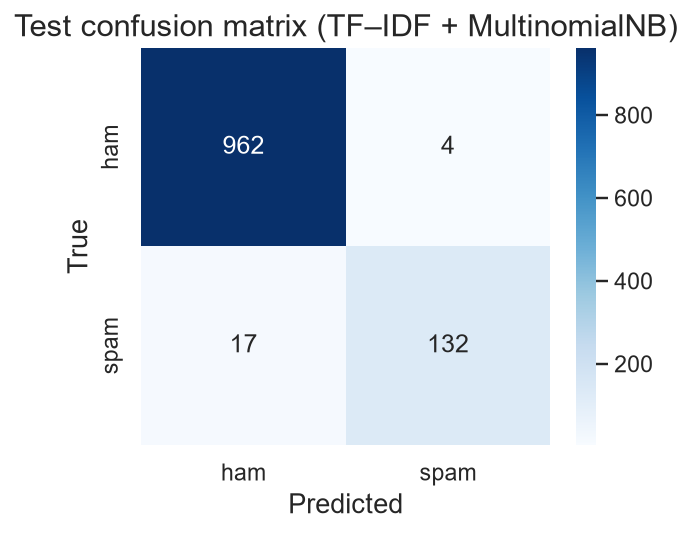

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.6, 4.0))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Test confusion matrix (TF–IDF + MultinomialNB)")
fig.tight_layout()
plt.show()


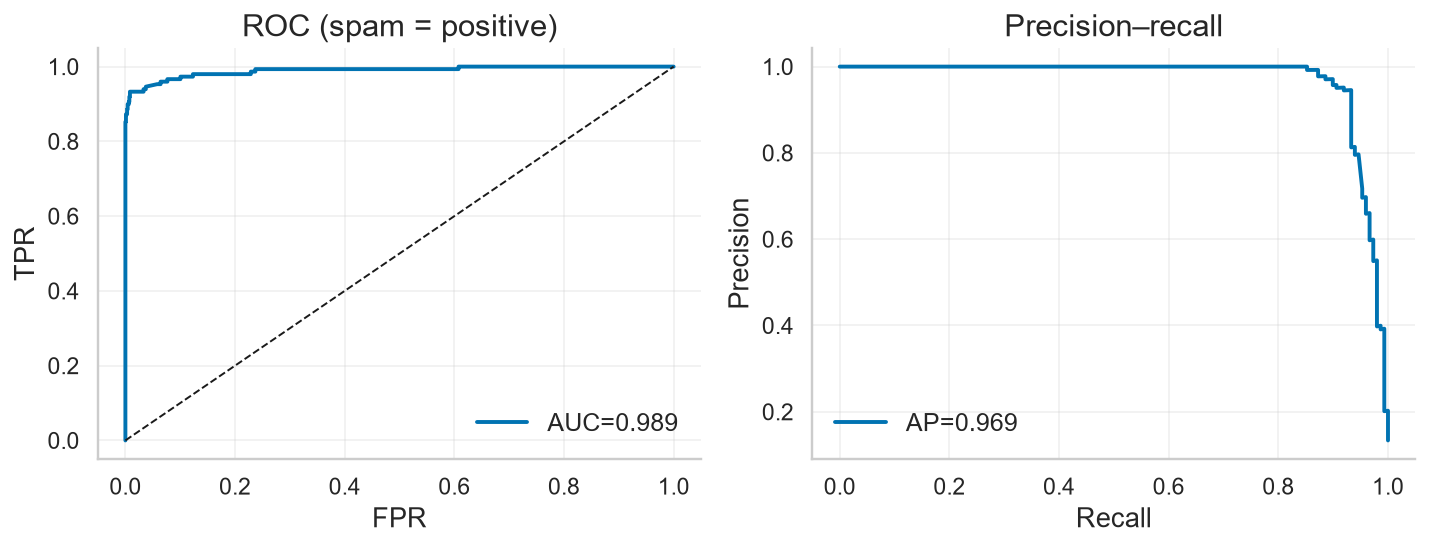

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_score)
p, r, _ = precision_recall_curve(y_test, y_score)
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.1))
axes[0].plot(fpr, tpr, lw=2, label=f"AUC={roc_auc_score(y_test, y_score):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC (spam = positive)")
axes[0].legend(frameon=False)
axes[1].plot(r, p, lw=2, label=f"AP={average_precision_score(y_test, y_score):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()


## 8. Most informative tokens (log-odds spam vs ham)

Using the fitted NB `feature_log_prob_` on the pipeline’s TF–IDF vocabulary:

$$
\Delta_v=\log P(w_v\mid\mathrm{spam})-\log P(w_v\mid\mathrm{ham}).
$$



 cell output


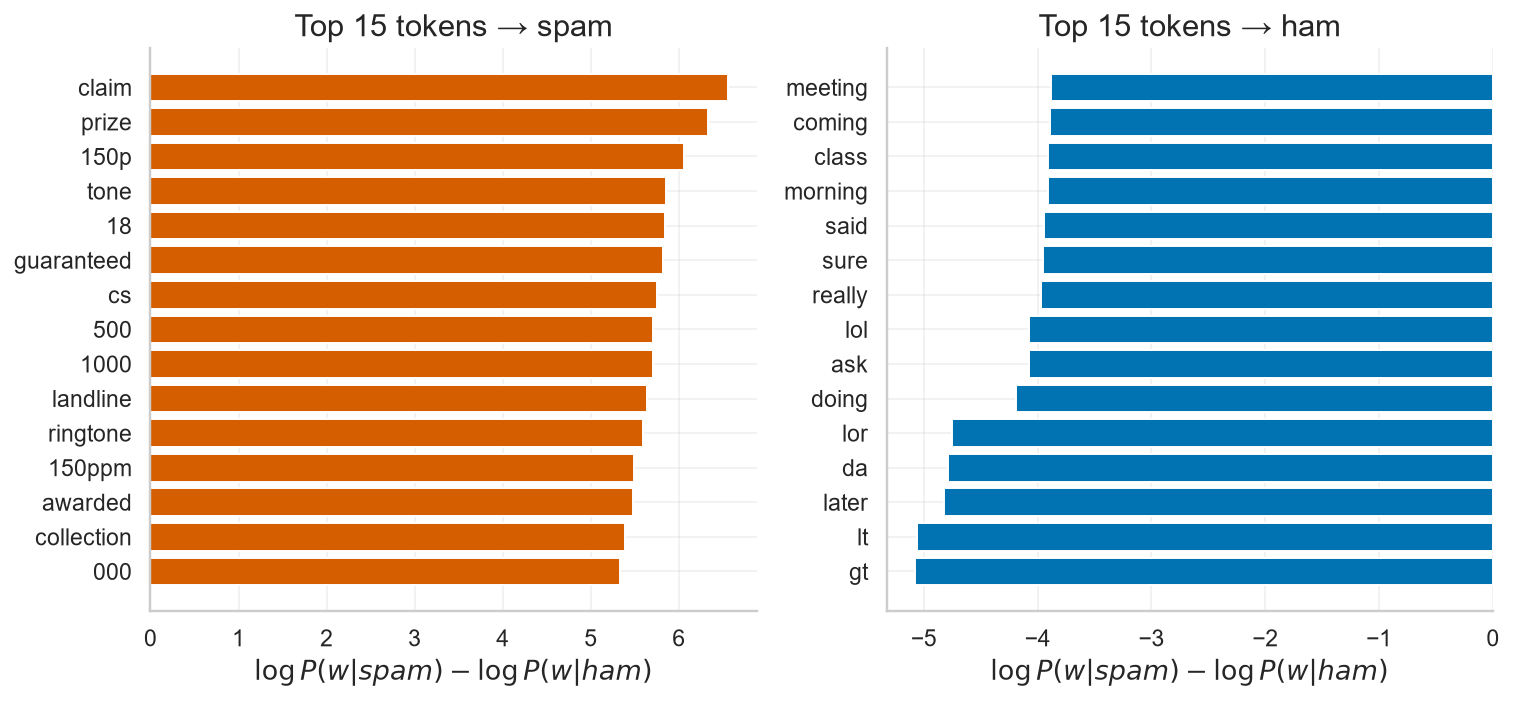

spam cues: ['claim', 'prize', '150p', 'tone', '18', 'guaranteed', 'cs', '500', '1000', 'landline', 'ringtone', '150ppm', 'awarded', 'collection', '000']
ham cues: ['gt', 'lt', 'later', 'da', 'lor', 'doing', 'ask', 'lol', 'really', 'sure', 'said', 'morning', 'class', 'coming', 'meeting']


In [11]:
_rule("cell output")
vec = clf.named_steps["tfidf"]
nbm = clf.named_steps["nb"]
vocab = np.array(vec.get_feature_names_out())
# classes_ are sorted: 0=ham, 1=spam
delta = nbm.feature_log_prob_[1] - nbm.feature_log_prob_[0]
top_spam = np.argsort(delta)[-15:][::-1]
top_ham = np.argsort(delta)[:15]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.2))
axes[0].barh(vocab[top_spam][::-1], delta[top_spam][::-1], color="C3")
axes[0].set_title("Top 15 tokens → spam")
axes[0].set_xlabel(r"$\log P(w|spam)-\log P(w|ham)$")
axes[1].barh(vocab[top_ham], delta[top_ham], color="C0")
axes[1].set_title("Top 15 tokens → ham")
axes[1].set_xlabel(r"$\log P(w|spam)-\log P(w|ham)$")
fig.tight_layout()
plt.show()
print("spam cues:", list(vocab[top_spam]))
print("ham cues:", list(vocab[top_ham]))


## 9. Novel SMS inference (lab “live” test)

The fitted pipeline maps raw strings → TF–IDF → $P(\mathrm{spam}\mid d)$. Threshold 0.5 for the label (tune threshold if you care more about precision or recall).


In [12]:
_rule("cell output")
novel = [
    "Hey, are we still on for dinner at 8?",
    "WINNER! Claim your FREE holiday voucher. Call 09001234567 now!",
    "I'll be home in 10 minutes, please heat the leftover pasta",
    "Urgent: your bank account is locked. Verify at http://not-a-bank.example",
    "k. see you tomorrow lecture",
    "Congratulations you have been selected for a £5000 cash prize txt WIN to 87021",
]
proba = clf.predict_proba(novel)[:, 1]
pred = clf.predict(novel)
live = pd.DataFrame({"sms": novel, "P_spam": np.round(proba, 4), "pred": np.where(pred == 1, "spam", "ham")})
print(live.to_string(index=False))



 cell output
                                                                           sms  P_spam pred
                                         Hey, are we still on for dinner at 8?  0.0017  ham
                WINNER! Claim your FREE holiday voucher. Call 09001234567 now!  0.9986 spam
                    I'll be home in 10 minutes, please heat the leftover pasta  0.0100  ham
      Urgent: your bank account is locked. Verify at http://not-a-bank.example  0.8845 spam
                                                   k. see you tomorrow lecture  0.0162  ham
Congratulations you have been selected for a £5000 cash prize txt WIN to 87021  0.9998 spam


## 10. Viva-voce

**Q1. Write Bayes’ rule for spam given a message.**  
**A.** $P(\mathrm{spam}\mid d)=P(d\mid\mathrm{spam})P(\mathrm{spam})/P(d)$.

**Q2. What is “naïve”?**  
**A.** Token occurrences are treated as independent given the class.

**Q3. Zero-probability problem?**  
**A.** MLE $P(w\mid c)=0$ if $w$ unseen in class $c$ zeroes the likelihood. Laplace $\alpha$ prevents that.

**Q4. Why $\log$ probabilities?**  
**A.** Products of tiny numbers underflow; sum of logs is stable.

**Q5. Count vs TF–IDF with MultinomialNB?**  
**A.** Counts match the multinomial story. TF–IDF often **still works** (and can help) as nonnegative features.

**Q6. Why stratify the split?**  
**A.** Spam is ~13%; a non-stratified test set can look artificially easy or hard.

**Q7. Is accuracy enough?**  
**A.** No. A ham-majority dummy is ~87% accurate. Use F1/ROC/PR for spam.

**Q8. What does $\alpha$ do?**  
**A.** Larger $\alpha$ smooths toward uniform $P(w\mid c)$; too large underfits.

**Q9. Why stopwords?**  
**A.** “the/you” add little class signal and inflate $V$. SMS slang may still matter (`u`, `ur`) — `min_df` and domain lists are design choices.

**Q10. Can NB output calibrated probabilities?**  
**A.** Not always. ROC still ranks well; for thresholds, consider calibration (beyond this lab).

**Q11. Independence is false. Why does it work?**  
**A.** Ranking of classes can stay correct even if probability estimates are off (Hand & Yu; Domingos).

**Q12. How would you deploy the “live” cell?**  
**A.** Persist `pipeline.joblib`; same `clean_sms` must run at inference.


## 11. Summary

- Parul outcome: **Naïve Bayes on text** — here **SMS ham/spam**.
- Laplace NB on bag-of-words is the exam derivation; sklearn + TF–IDF is the lab system.
- Scratch NumPy matches sklearn `feature_log_prob_` on counts.
- Always report **spam F1 / ROC**, not accuracy alone; inspect **tokens** that drive $\Delta_v$.

Do not modify `extra/`.

---
*End of Practical 08. Record load origin, $n$, best $\alpha$, test F1/AUC, and two novel-SMS predictions. Kernel: `ml-lab-kernel`.*
